# Week 9 Evaluating Model Performance
> by Lei Ding, Updated Apr. 2025

In [1]:
# 准备
#install.packages('caTools')
#install.packages('caret')
#install.packages('titanic')
#install.packages('ROCR')

## 1. 留出法

In [2]:
# run数据集上使用留出法
firstrun <- rnorm(99, 30, 10)
secondrun <- firstrun + rnorm(99, 5, 2)
finalrun <- secondrun + rnorm(99, 7, 3)
run <- data.frame(firstrun, secondrun, finalrun)
head(run)

,firstrun,secondrun,finalrun
,<dbl>,<dbl>,<dbl>
1,24.40495,27.54216,31.15539
2,31.47915,36.15551,43.66317
3,30.65454,35.09042,41.94772
4,39.01523,42.04798,50.75917
5,39.77104,45.66055,49.09833
6,17.65785,18.61169,24.78229


In [3]:
idx <- sample(nrow(run), size=round(nrow(run) * 0.8))
train_run <- run[idx,]
test_run <- run[-idx,]

str(train_run)

'data.frame':	79 obs. of  3 variables:
 $ firstrun : num  31.1 42.6 32.1 34.3 17 ...
 $ secondrun: num  39.4 51 34.1 40.8 23.4 ...
 $ finalrun : num  49.7 57 41.8 50 30 ...


In [4]:
str(test_run)

'data.frame':	20 obs. of  3 variables:
 $ firstrun : num  31.5 39 39.8 37.7 27 ...
 $ secondrun: num  36.2 42 45.7 41.1 32.6 ...
 $ finalrun : num  43.7 50.8 49.1 54.5 37 ...


In [5]:
# 泰坦尼克数据集上使用留出法
library(titanic)
data(titanic_train)

df = titanic_train
head(df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,,S
2,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,,S
4,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
5,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,,S
6,6,0,3,"Moran, Mr. James",male,NA,0,0,330877,8.4583,,Q


In [6]:
library(caTools)
split <- sample.split(df$Survived, SplitRatio=0.70)  # 分层抽样
df_train <- subset(df, split==TRUE)
df_test <- subset(df, split==FALSE)

table(df_train$Survived)


  0   1 
384 239 

In [7]:
table(df_test$Survived)


  0   1 
165 103 

In [8]:
# iris数据集上使用留出法
data(iris)
split = 0.80

library(caret)
trainIndex <- createDataPartition(iris$Species, p=split, list=FALSE)  # 分层抽样

data_train <- iris[trainIndex, ]
data_test <- iris[-trainIndex, ]

table(data_train$Species)

Loading required package: ggplot2

Loading required package: lattice




    setosa versicolor  virginica 
        40         40         40 

In [9]:
table(data_test$Species)


    setosa versicolor  virginica 
        10         10         10 

In [10]:
library(C50)
model <- C5.0(x=data_train[, -5], y=data_train$Species)

x_test <- data_test[, 1:4]
y_test <- data_test[, 5]

predictions <- predict(model, x_test)
confusionMatrix(predictions, y_test)

Confusion Matrix and Statistics

            Reference
Prediction   setosa versicolor virginica
  setosa         10          0         0
  versicolor      0         10         0
  virginica       0          0        10

Overall Statistics
                                     
               Accuracy : 1          
                 95% CI : (0.8843, 1)
    No Information Rate : 0.3333     
    P-Value [Acc > NIR] : 4.857e-15  
                                     
                  Kappa : 1          
                                     
 Mcnemar's Test P-Value : NA         

Statistics by Class:

                     Class: setosa Class: versicolor Class: virginica
Sensitivity                 1.0000            1.0000           1.0000
Specificity                 1.0000            1.0000           1.0000
Pos Pred Value              1.0000            1.0000           1.0000
Neg Pred Value              1.0000            1.0000           1.0000
Prevalence                  0.3333            

In [11]:
# 简单随机抽样下样本并不均衡
train_ind_1 <- sample(1:nrow(iris), size=nrow(iris) * 0.7, replace=FALSE)
data_train_1 <- iris[train_ind_1, ]

table(data_train_1$Species)


    setosa versicolor  virginica 
        39         34         32 

## 2. 交叉验证

In [12]:
# 10折交叉验证
library(caret)
train_control <- trainControl(method='cv', number=10)
model <- train(Species ~ ., data=iris, trControl=train_control, method='knn')
model

k-Nearest Neighbors 

150 samples
  4 predictor
  3 classes: 'setosa', 'versicolor', 'virginica' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 135, 135, 135, 135, 135, 135, ... 
Resampling results across tuning parameters:

  k  Accuracy   Kappa
  5  0.9600000  0.94 
  7  0.9666667  0.95 
  9  0.9600000  0.94 

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was k = 7.

In [13]:
# 重复交叉验证
train_control <- trainControl(method='repeatedcv', number=10, repeats=3)
model <- train(Species ~ ., data=iris, trControl=train_control, method='knn')
model

k-Nearest Neighbors 

150 samples
  4 predictor
  3 classes: 'setosa', 'versicolor', 'virginica' 

No pre-processing
Resampling: Cross-Validated (10 fold, repeated 3 times) 
Summary of sample sizes: 135, 135, 135, 135, 135, 135, ... 
Resampling results across tuning parameters:

  k  Accuracy   Kappa    
  5  0.9711111  0.9566667
  7  0.9733333  0.9600000
  9  0.9777778  0.9666667

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was k = 9.

In [14]:
# caret包中train支持的机器学习算法
names(caret::getModelInfo())

[1] "ada"                 "AdaBag"              "AdaBoost.M1"        
  [4] "adaboost"            "amdai"               "ANFIS"              
  [7] "avNNet"              "awnb"                "awtan"              
 [10] "bag"                 "bagEarth"            "bagEarthGCV"        
 [13] "bagFDA"              "bagFDAGCV"           "bam"                
 [16] "bartMachine"         "bayesglm"            "binda"              
 [19] "blackboost"          "blasso"              "blassoAveraged"     
 [22] "bridge"              "brnn"                "BstLm"              
 [25] "bstSm"               "bstTree"             "C5.0"               
 [28] "C5.0Cost"            "C5.0Rules"           "C5.0Tree"           
 [31] "cforest"             "chaid"               "CSimca"             
 [34] "ctree"               "ctree2"              "cubist"             
 [37] "dda"                 "deepboost"           "DENFIS"             
 [40] "dnn"                 "dwdLinear"           "dwdPoly"            
 [43] "dwdRadial"           "earth"               "elm"                
 [46] "enet"                "evtree"              "extraTrees"         
 [49] "fda"                 "FH.GBML"             "FIR.DM"             
 [52] "foba"                "FRBCS.CHI"           "FRBCS.W"            
 [55] "FS.HGD"              "gam"                 "gamboost"           
 [58] "gamLoess"            "gamSpline"           "gaussprLinear"      
 [61] "gaussprPoly"         "gaussprRadial"       "gbm_h2o"            
 [64] "gbm"                 "gcvEarth"            "GFS.FR.MOGUL"       
 [67] "GFS.LT.RS"           "GFS.THRIFT"          "glm.nb"             
 [70] "glm"                 "glmboost"            "glmnet_h2o"         
 [73] "glmnet"              "glmStepAIC"          "gpls"               
 [76] "hda"                 "hdda"                "hdrda"              
 [79] "HYFIS"               "icr"                 "J48"                
 [82] "JRip"                "kernelpls"           "kknn"               
 [85] "knn"                 "krlsPoly"            "krlsRadial"         
 [88] "lars"                "lars2"               "lasso"              
 [91] "lda"                 "lda2"                "leapBackward"       
 [94] "leapForward"         "leapSeq"             "Linda"              
 [97] "lm"                  "lmStepAIC"           "LMT"                
[100] "loclda"              "logicBag"            "LogitBoost"         
[103] "logreg"              "lssvmLinear"         "lssvmPoly"          
[106] "lssvmRadial"         "lvq"                 "M5"                 
[109] "M5Rules"             "manb"                "mda"                
[112] "Mlda"                "mlp"                 "mlpKerasDecay"      
[115] "mlpKerasDecayCost"   "mlpKerasDropout"     "mlpKerasDropoutCost"
[118] "mlpML"               "mlpSGD"              "mlpWeightDecay"     
[121] "mlpWeightDecayML"    "monmlp"              "msaenet"            
[124] "multinom"            "mxnet"               "mxnetAdam"          
[127] "naive_bayes"         "nb"                  "nbDiscrete"         
[130] "nbSearch"            "neuralnet"           "nnet"               
[133] "nnls"                "nodeHarvest"         "null"               
[136] "OneR"                "ordinalNet"          "ordinalRF"          
[139] "ORFlog"              "ORFpls"              "ORFridge"           
[142] "ORFsvm"              "ownn"                "pam"                
[145] "parRF"               "PART"                "partDSA"            
[148] "pcaNNet"             "pcr"                 "pda"                
[151] "pda2"                "penalized"           "PenalizedLDA"       
[154] "plr"                 "pls"                 "plsRglm"            
[157] "polr"                "ppr"                 "pre"                
[160] "PRIM"                "protoclass"          "qda"                
[163] "QdaCov"              "qrf"                 "qrnn"               
[166] "randomGLM"           "ranger"      

## 3. 按概率输出

In [15]:
library(caret)
trainIndex <- createDataPartition(iris$Species, p=0.80, list=FALSE)
data_train <- iris[trainIndex, ]
data_test <- iris[-trainIndex, ]

# 输出类别
library(C50)
model <- C5.0(x=data_train[, -5], y=data_train$Species)
predictions <- predict(model, data_test[, 1:4])
predictions

[1] setosa     setosa     setosa     setosa     setosa     setosa    
 [7] setosa     setosa     versicolor setosa     versicolor versicolor
[13] versicolor virginica  versicolor versicolor versicolor versicolor
[19] versicolor versicolor virginica  virginica  versicolor virginica 
[25] virginica  virginica  virginica  versicolor virginica  virginica 
Levels: setosa versicolor virginica

In [16]:
# 输出预测概率
predictions <- predict(model, data_test[, 1:4], type='prob')
predictions

,setosa,versicolor,virginica
1,0.983739837,0.008130082,0.008130082
20,0.983739837,0.008130082,0.008130082
21,0.983739837,0.008130082,0.008130082
28,0.983739837,0.008130082,0.008130082
36,0.983739837,0.008130082,0.008130082
40,0.983739837,0.008130082,0.008130082
42,0.983739837,0.008130082,0.008130082
43,0.983739837,0.008130082,0.008130082
44,0.008547009,0.982905982,0.008547009
47,0.983739837,0.008130082,0.008130082


In [17]:
# 决策树的概率输出
model1 <- train(Species ~., data=data_train, method='C5.0', tuneLength=1)
# 数据集过小，tuneLength=1不再对C5.0的trails超参数调优

predictions <- predict(model1, data_test[, 1:4], type='prob')
predictions

,setosa,versicolor,virginica
,<dbl>,<dbl>,<dbl>
1,1,0.0000000,0.0000000
20,1,0.0000000,0.0000000
21,1,0.0000000,0.0000000
28,1,0.0000000,0.0000000
36,1,0.0000000,0.0000000
40,1,0.0000000,0.0000000
42,1,0.0000000,0.0000000
43,1,0.0000000,0.0000000
44,0,1.0000000,0.0000000


## 4. 混淆矩阵

In [18]:
library(caret)
expected <- factor(c(1, 1, 0, 1, 0, 0, 1, 0, 0, 0))
predicted <- factor(c(1, 0, 0, 1, 0, 0, 1, 1, 1, 0))
results <- confusionMatrix(data=predicted, reference=expected)
results

Confusion Matrix and Statistics

          Reference
Prediction 0 1
         0 4 1
         1 2 3
                                          
               Accuracy : 0.7             
                 95% CI : (0.3475, 0.9333)
    No Information Rate : 0.6             
    P-Value [Acc > NIR] : 0.3823          
                                          
                  Kappa : 0.4             
                                          
 Mcnemar's Test P-Value : 1.0000          
                                          
            Sensitivity : 0.6667          
            Specificity : 0.7500          
         Pos Pred Value : 0.8000          
         Neg Pred Value : 0.6000          
             Prevalence : 0.6000          
         Detection Rate : 0.4000          
   Detection Prevalence : 0.5000          
      Balanced Accuracy : 0.7083          
                                          
       'Positive' Class : 0               
                                          

## 5. 受试者工作特征曲线

In [19]:
library(ROCR)
sms_results <- read.csv("sms_results.csv")
sms_results_knn <- read.csv("sms_results_knn.csv")
# https://github.com/dataspelunking/MLwR/

head(sms_results)

,actual_type,predict_type,prob_spam,prob_ham
,<chr>,<chr>,<dbl>,<dbl>
1,ham,ham,0.00000,1.00000
2,ham,ham,0.00000,1.00000
3,ham,ham,0.00016,0.99984
4,ham,ham,0.00004,0.99996
5,spam,spam,1.00000,0.00000
6,ham,ham,0.00020,0.99980


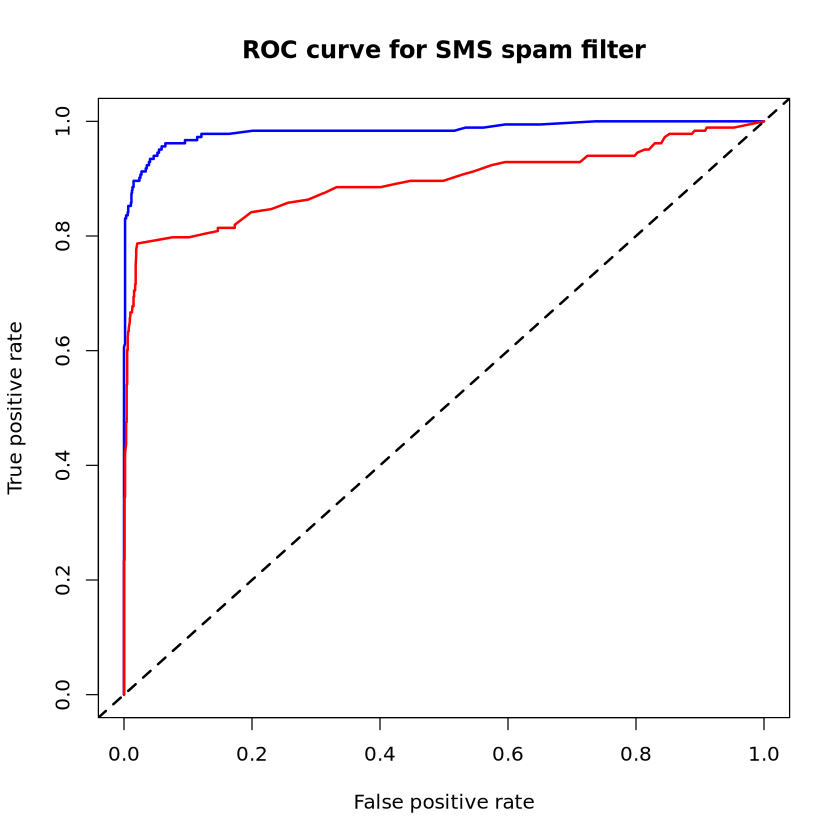

In [20]:
pred <- prediction(predictions=sms_results$prob_spam, labels=sms_results$actual_type)
pred_knn <- prediction(predictions=sms_results_knn$p_spam, labels=sms_results$actual_type)
perf <- performance(pred, measure="tpr", x.measure="fpr")
perf_knn <- performance(pred_knn, measure="tpr", x.measure="fpr")

plot(perf, main="ROC curve for SMS spam filter", col="blue", lwd=2)
plot(perf_knn, main="ROC curve for SMS spam filter", col="red", lwd=2, add=TRUE)
abline(a=0, b=1, lwd=2, lty=2)

# 蓝色ROC曲线对应的分类器比红色好

In [21]:
# 计算AUC值
perf.auc <- performance(pred, measure="auc")
str(perf.auc)
as.numeric(perf.auc@y.values)

Formal class 'performance' [package "ROCR"] with 6 slots
  ..@ x.name      : chr "None"
  ..@ y.name      : chr "Area under the ROC curve"
  ..@ alpha.name  : chr "none"
  ..@ x.values    : list()
  ..@ y.values    :List of 1
  .. ..$ : num 0.984
  ..@ alpha.values: list()


[1] 0.9835862

In [22]:
perf_knn.auc <- performance(pred_knn, measure = "auc")
str(perf_knn.auc)
as.numeric(perf_knn.auc@y.values)

Formal class 'performance' [package "ROCR"] with 6 slots
  ..@ x.name      : chr "None"
  ..@ y.name      : chr "Area under the ROC curve"
  ..@ alpha.name  : chr "none"
  ..@ x.values    : list()
  ..@ y.values    :List of 1
  .. ..$ : num 0.894
  ..@ alpha.values: list()


[1] 0.8941987